In [ ]:

!pip install contractions
!pip install wordcloud
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import contractions

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

In [ ]:
nltk.download('stopwords')

nltk.download('wordnet')

nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/3. Financial Phrase Dataset"

df = pd.read_csv("/content/drive/MyDrive/3. Financial Phrase Dataset/financial_phrase.csv")

print("Dataset shape:")

print(df.shape)

print("\nFirst 5 rows:")

df.head()

Dataset shape:
(2264, 2)

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [ ]:
#Understanding the datasets

print("Columns:")

print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['label'].value_counts())

Columns:
Index(['text', 'label'], dtype='object')

Missing values:
text     0
label    0
dtype: int64

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


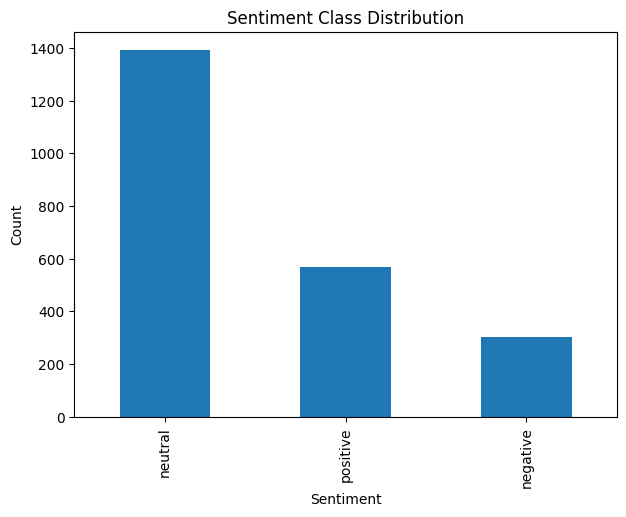

In [ ]:
#Graph for class distribution

df['label'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Sentiment Class Distribution")

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [ ]:
#Text cleaning
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = []

    for word in words:

        if word not in stop_words:

            lemma = lemmatizer.lemmatize(word)

            cleaned_words.append(lemma)

    return " ".join(cleaned_words)

In [ ]:
#Applying the text cleaning

df['cleaned_text'] = df['text'].astype(str).apply(clean_text)

print(df[['text', 'cleaned_text']].head())

                                                text  \
0  According to Gran , the company has no plans t...   
1  For the last quarter of 2010 , Componenta 's n...   
2  In the third quarter of 2010 , net sales incre...   
3  Operating profit rose to EUR 13.1 mn from EUR ...   
4  Operating profit totalled EUR 21.1 mn , up fro...   

                                        cleaned_text  
0  according gran company plan move production ru...  
1  last quarter componenta net sale doubled eurm ...  
2  third quarter net sale increased eur mn operat...  
3  operating profit rose eur mn eur mn correspond...  
4  operating profit totalled eur mn eur mn repres...  


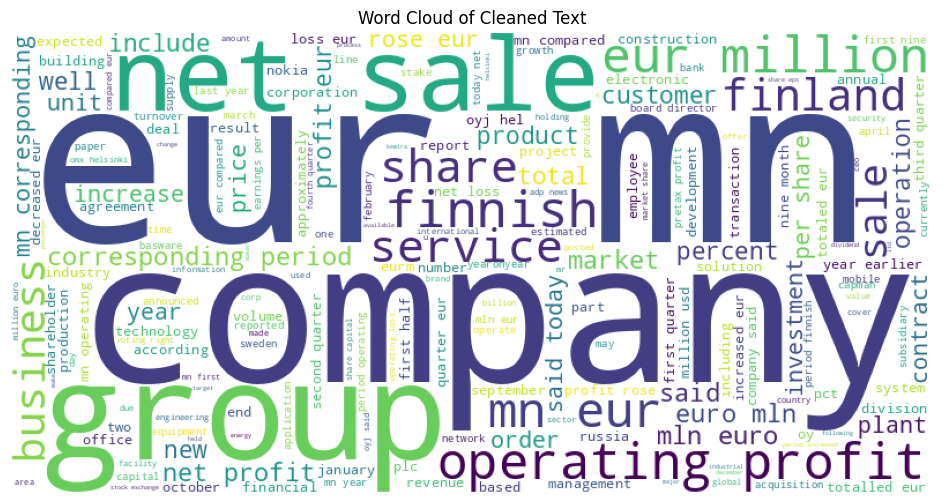

In [ ]:
# WORD CLOUD
all_words = " ".join(df['cleaned_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Cleaned Text")

plt.show()

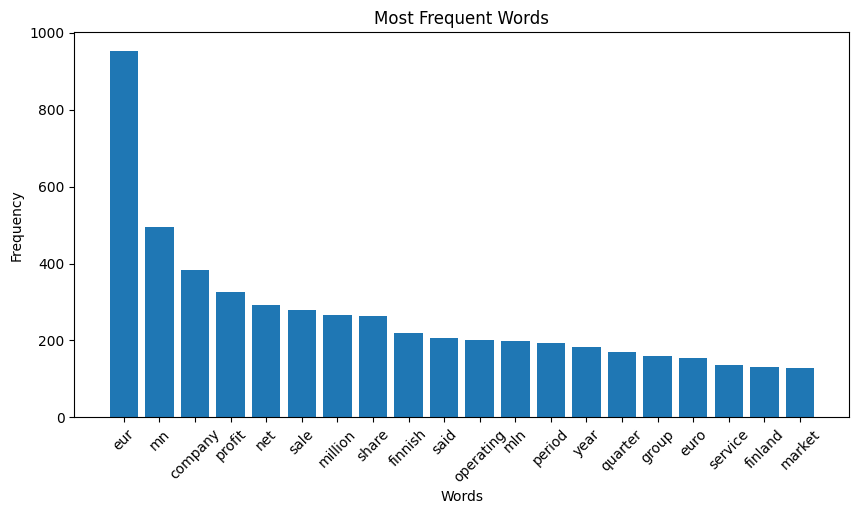

In [ ]:
# Most frequently used words

from collections import Counter

all_words_list = all_words.split()

word_freq = Counter(all_words_list)

most_common = word_freq.most_common(20)

words = [item[0] for item in most_common]
counts = [item[1] for item in most_common]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Most Frequent Words")

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# LABEL ENCODING
encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(df['label'])

print("Label mapping:")

for i, label in enumerate(encoder.classes_):
    print(label, "->", i)

Label mapping:
negative -> 0
neutral -> 1
positive -> 2


In [ ]:
# TRAIN TEST SPLIT
X = df['cleaned_text']

y = df['encoded_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1811
Testing samples: 453


In [ ]:
# TOKENIZATION

VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

Vocabulary size: 4424


In [ ]:
# Padding

# Using percentile-based padding
sequence_lengths = [len(seq) for seq in X_train_sequences]

MAX_LENGTH = int(np.percentile(sequence_lengths, 95))

print("Max sequence length:", MAX_LENGTH)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding='post'
)

print("Padded training shape:", X_train_padded.shape)
print("Padded testing shape:", X_test_padded.shape)

Max sequence length: 22
Padded training shape: (1811, 22)
Padded testing shape: (453, 22)


In [ ]:
#Early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# SIMPLE RNN MODEL
rnn_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN SIMPLE RNN
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_time = time.time() - start_time

print("RNN training time:", round(rnn_time,2), "seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6354 - loss: 0.8883 - val_accuracy: 0.7355 - val_loss: 0.6980
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7583 - loss: 0.6193 - val_accuracy: 0.7355 - val_loss: 0.6244
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8785 - loss: 0.3202 - val_accuracy: 0.7080 - val_loss: 0.6841
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9579 - loss: 0.1397 - val_accuracy: 0.7410 - val_loss: 0.7513
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9731 - loss: 0.0791 - val_accuracy: 0.7218 - val_loss: 0.8981
RNN training time: 9.24 seconds


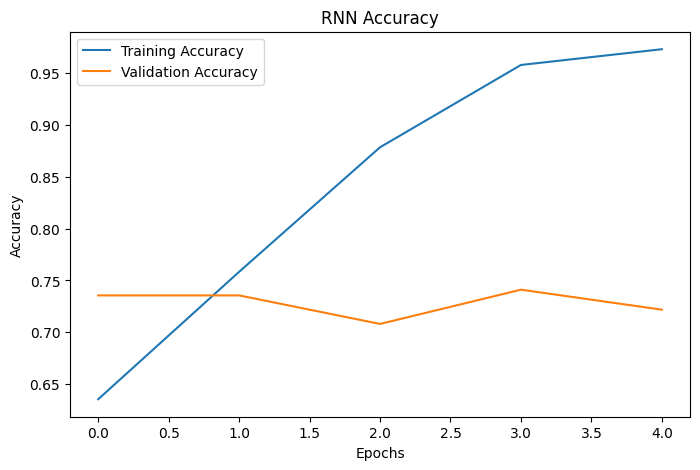

In [ ]:
# RNN ACCURACY GRAPH
plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("RNN Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


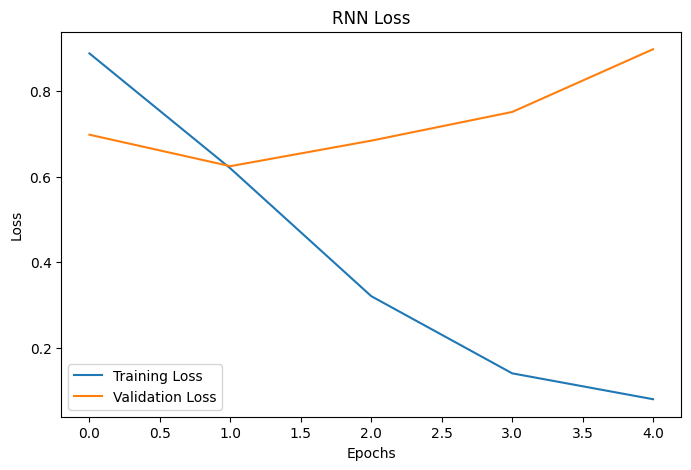

In [ ]:
# RNN LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("RNN Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
#LSTM Model
lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training LSTM Model

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

lstm_time = time.time() - start_time

print("LSTM training time:", round(lstm_time,2), "seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6222 - loss: 0.9259 - val_accuracy: 0.6667 - val_loss: 0.7772
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7535 - loss: 0.5618 - val_accuracy: 0.7851 - val_loss: 0.5739
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8260 - loss: 0.3940 - val_accuracy: 0.7410 - val_loss: 0.6056
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8494 - loss: 0.3310 - val_accuracy: 0.7741 - val_loss: 0.5794
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8529 - loss: 0.2897 - val_accuracy: 0.7548 - val_loss: 0.6705
LSTM training time: 9.14 seconds


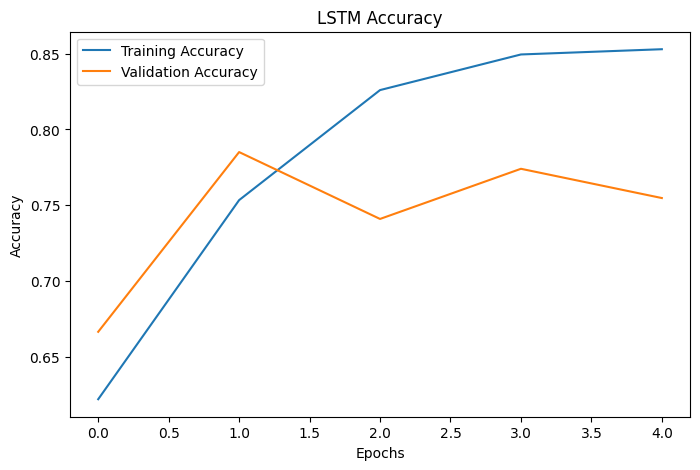

In [ ]:
# LSTM ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


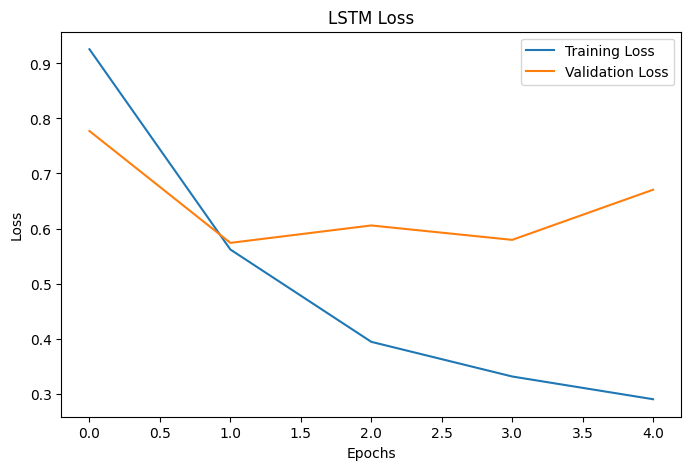

In [ ]:
# LSTM LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# Loading pretrained WORD2VEC
embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
# Create embedding matrix
embedding_dim = 50

embedding_matrix = np.zeros(
    (VOCAB_SIZE, embedding_dim)
)

for word, i in word_index.items():

    if i >= VOCAB_SIZE:
        continue

    if word in embedding_model:

        embedding_vector = embedding_model[word]

        embedding_matrix[i] = embedding_vector

In [ ]:
# LSTM with WORD2VEC embeddings

word2vec_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

word2vec_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

word2vec_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
# Training WORD2VEC LSTM

start_time = time.time()

word2vec_history = word2vec_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

word2vec_time = time.time() - start_time

print("Word2Vec LSTM training time:", round(word2vec_time,2), "seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6657 - loss: 0.8172 - val_accuracy: 0.7466 - val_loss: 0.6544
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7376 - loss: 0.6154 - val_accuracy: 0.7686 - val_loss: 0.5779
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7472 - loss: 0.5788 - val_accuracy: 0.7631 - val_loss: 0.5588
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7507 - loss: 0.5479 - val_accuracy: 0.7658 - val_loss: 0.5655
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7686 - loss: 0.5314 - val_accuracy: 0.7879 - val_loss: 0.5264
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7742 - loss: 0.4965 - val_accuracy: 0.7769 - val_loss: 0.5206
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7811 - loss: 0.4639 - val_accuracy: 0.7796 - val_loss: 0.5053
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7811 - loss: 0.4459 - val_accuracy: 0.7686 - v

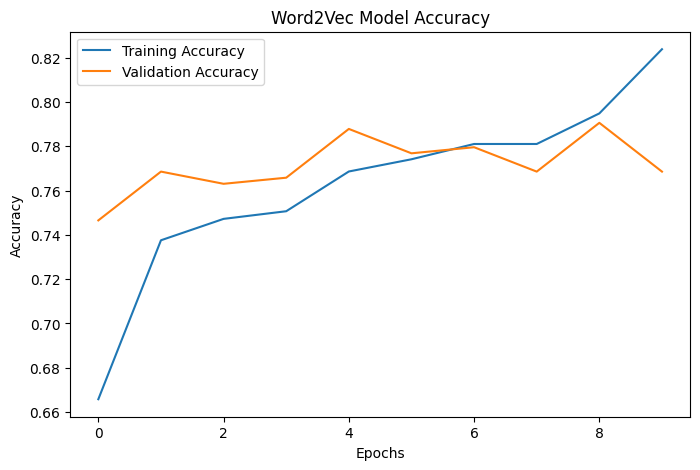

In [ ]:
# WORD2VEC ACCURACY GRAPH
plt.figure(figsize=(8,5))

plt.plot(
    word2vec_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    word2vec_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Word2Vec Model Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

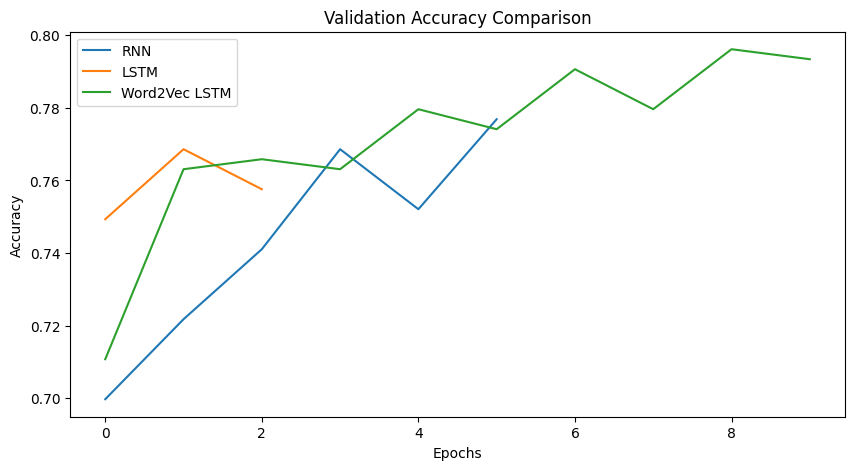

In [ ]:
#Plot accuracy comparison

plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(word2vec_history.history['val_accuracy'], label='Word2Vec LSTM')

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
#Modles evaluation

rnn_loss, rnn_acc = rnn_model.evaluate(X_test_padded, y_test)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_padded, y_test)

word2vec_loss, word2vec_acc = word2vec_model.evaluate(X_test_padded, y_test)

print("RNN Accuracy:", round(rnn_acc * 100,2), "%")

print("LSTM Accuracy:", round(lstm_acc * 100,2), "%")

print("Word2Vec LSTM Accuracy:", round(word2vec_acc * 100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7638 - loss: 0.5715 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7572 - loss: 0.5782
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7815 - loss: 0.5286
RNN Accuracy: 76.38 %
LSTM Accuracy: 75.72 %
Word2Vec LSTM Accuracy: 78.15 %


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


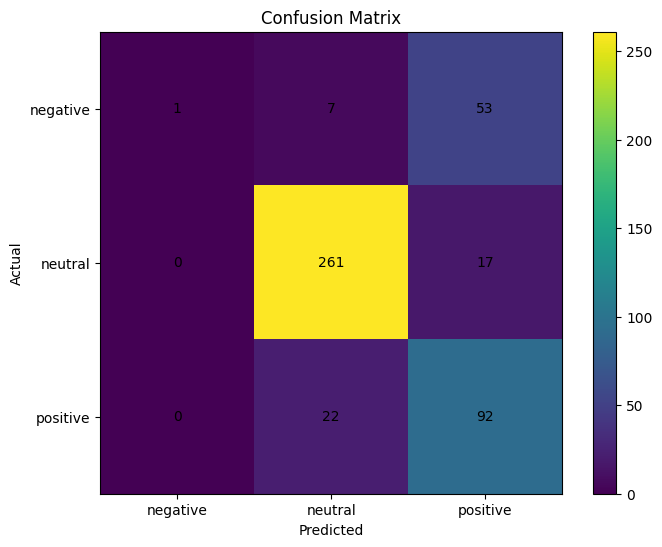

In [ ]:
#Confusion Matrix

y_pred_prob = word2vec_model.predict(X_test_padded)

y_pred = np.argmax(y_pred_prob, axis=1)

labels = encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [ ]:
#Classification report

print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))

              precision    recall  f1-score   support

    negative       1.00      0.02      0.03        61
     neutral       0.90      0.94      0.92       278
    positive       0.57      0.81      0.67       114

    accuracy                           0.78       453
   macro avg       0.82      0.59      0.54       453
weighted avg       0.83      0.78      0.74       453



In [ ]:
#Error analysis

misclassified = []

for i in range(len(y_test)):

    if y_test.iloc[i] != y_pred[i]:

        misclassified.append(i)

print("Total misclassified examples:", len(misclassified))

for i in misclassified[:3]:

    print("\nTEXT:")
    print(X_test.iloc[i])

    print("Actual Label:", encoder.inverse_transform([y_test.iloc[i]])[0])

    print("Predicted Label:", encoder.inverse_transform([y_pred[i]])[0])

Total misclassified examples: 99

TEXT:
september alone market declined percent yearonyear million liter
Actual Label: negative
Predicted Label: positive

TEXT:
raute reported loss per share eur first half eps eur corresponding period
Actual Label: negative
Predicted Label: positive

TEXT:
finnish electronics contract manufacturer scanfil report net sale eur mn second quarter eur mn year earlier
Actual Label: negative
Predicted Label: positive


           Model  Accuracy
0     Simple RNN     76.38
1           LSTM     75.72
2  Word2Vec LSTM     78.15


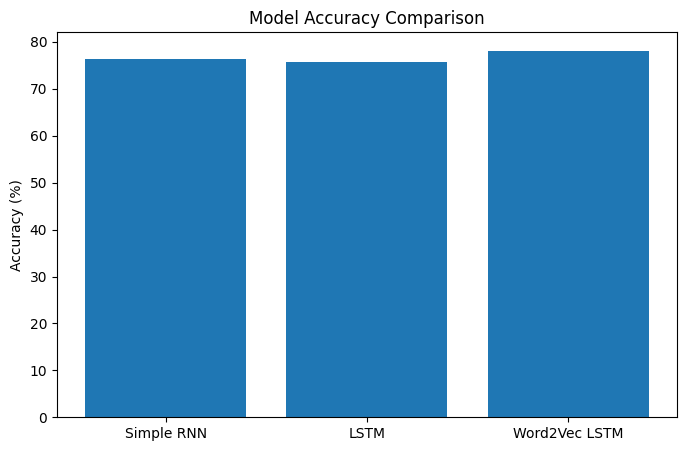

In [ ]:
#Comparing all modles
results = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        round(rnn_acc * 100,2),
        round(lstm_acc * 100,2),
        round(word2vec_acc * 100,2)
    ]
})

print(results)

plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy'])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.show()

# Conclusion

In this project, three deep learning models were used for financial sentiment analysis: Simple RNN, LSTM, and LSTM with pretrained Word2Vec embeddings.

Before training the models, text preprocessing was performed. This included lowercase conversion, removing URLs, special characters, stopwords, and lemmatization. The cleaned text was then tokenized and padded to create equal sequence lengths.

The Simple RNN model was able to learn sequential patterns in the text, but LSTM performed better because it can preserve long-term information more effectively. The Word2Vec LSTM model further improved performance because pretrained embeddings provide meaningful word representations learned from large text corpora.

The confusion matrix and classification report helped analyze the strengths and weaknesses of the final model. Error analysis showed that some financial sentences are difficult to classify because they contain mixed or ambiguous sentiment.

Overall, the LSTM with Word2Vec embeddings achieved the best performance and demonstrated the importance of pretrained embeddings in NLP tasks.